<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [116]:
# Check for GPU
!nvidia-smi

Sat Apr 25 19:00:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.64.03              Driver Version: 575.64.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2070        Off |   00000000:01:00.0  On |                  N/A |
| 43%   38C    P5             17W /  175W |     614MiB /   8192MiB |     36%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [117]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code


2.11.0+cu130


## 1. What are 3 areas in industry where computer vision is currently being used?

In [118]:
# robotics, av, and healthcare

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [119]:
import torch
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"The device is {device}")

The device is cpu


In [120]:
train_data = datasets.MNIST(
    root=".",
    train=True,
    download=True,
    transform=ToTensor(),
)

test_data = datasets.MNIST(
    root=".",
    train=False,
    download=True,
    transform=ToTensor(),
)

In [121]:
print(train_data, test_data)

image, label = train_data[0]

print(image.shape)

print(train_data.classes)

Dataset MNIST
    Number of datapoints: 60000
    Root location: .
    Split: Train
    StandardTransform
Transform: ToTensor() Dataset MNIST
    Number of datapoints: 10000
    Root location: .
    Split: Test
    StandardTransform
Transform: ToTensor()
torch.Size([1, 28, 28])
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


## 6. Visualize at least 5 different samples of the MNIST training dataset.

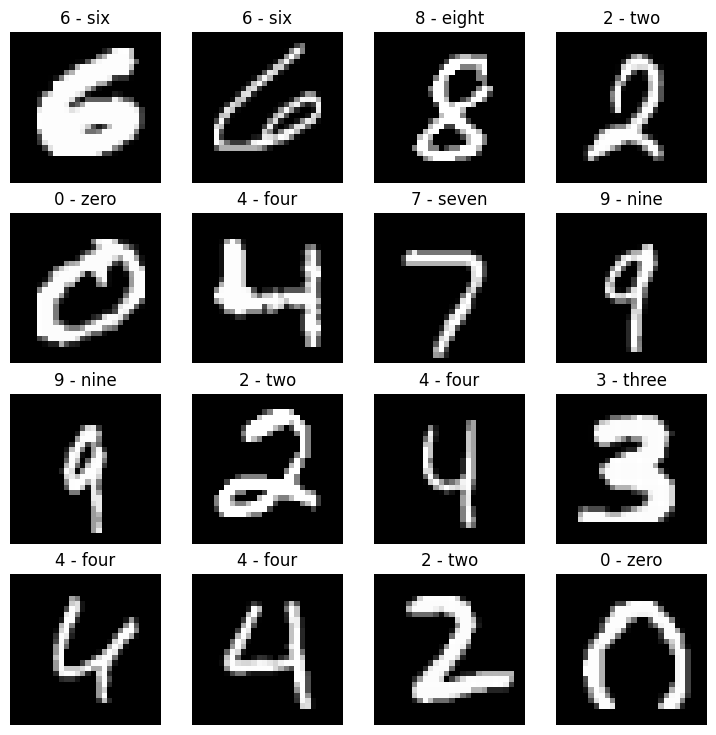

In [122]:
import matplotlib.pyplot as plt

torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(train_data.classes[label])
    plt.axis(False)

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [123]:
BATCH_SIZE = 32

from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Because for 1 batch, our shape is [32, 1, 28, 28] because each loader is 32 images 
# labels are 32 because 1 label for each image

train_features_batch, train_labels_batch = next(iter(train_dataloader))

train_features_batch.shape


torch.Size([32, 1, 28, 28])

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [124]:
from torch import nn

class ModelMNIST0(nn.Module):
    def __init__(self, input_shape, hidden_units, out_shape):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=out_shape),
        )

    def forward(self, x):
        return self.layers(x)

torch.manual_seed(42)
model0 = ModelMNIST0(input_shape=784, hidden_units=10, out_shape=len(train_data.classes)).to(device)
print(model0.parameters)

<bound method Module.parameters of ModelMNIST0(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
    (5): Linear(in_features=10, out_features=10, bias=True)
  )
)>


## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [125]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model0.parameters(),
    lr=0.01
)

In [126]:
!pip -q install torchmetrics # Colab doesn't come with torchmetrics
from torchmetrics import Accuracy

# MNIST has 10 classes
acc_fn = Accuracy(task="multiclass", num_classes=len(train_data.classes)).to(device)
acc_fn

MulticlassAccuracy()

In [127]:
def train_loop(
        model, 
        data_loader, 
        loss_fn, 
        optimizer,
        acc_fn, 
        device=device
        ):
    
    train_loss, train_acc = 0, 0
    model.to(device)

    for batch, (X, y) in enumerate(data_loader):

        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += acc_fn(y_pred.argmax(dim=1), y).item()
        
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train Acc: {train_acc*100:.2f}%")

def test_loop(
        model, 
        data_loader, 
        loss_fn, 
        acc_fn,
        device=device
        ):
    
    test_loss, test_acc = 0, 0

    model.to(device)
    model.eval()

    with torch.inference_mode():

        for X, y in data_loader:
            
            X = X.to(device)
            y = y.to(device)

            test_pred = model(X)

            test_loss += loss_fn(test_pred, y).item()
            test_acc += acc_fn(test_pred.argmax(dim=1), y).item()
        
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test Acc: {test_acc*100:.2f}%")

In [128]:
torch.manual_seed(42)

epochs = 3

for epoch in range(epochs):

    print(f"Epoch: {epoch}\n------")
    train_loop(model0, train_dataloader, loss_fn, optimizer, acc_fn, device)

    test_loop(model0, test_dataloader, loss_fn, acc_fn, device)
    


Epoch: 0
------
Train loss: 1.41932 | Train Acc: 53.88%
Test loss: 0.60466 | Test Acc: 81.22%
Epoch: 1
------
Train loss: 0.52387 | Train Acc: 83.87%
Test loss: 0.44291 | Test Acc: 86.10%
Epoch: 2
------
Train loss: 0.41937 | Train Acc: 87.47%
Test loss: 0.38288 | Test Acc: 88.25%


In [129]:
# Make the Tiny VGG archeitcutre
class TinyVGG(nn.Module):

    def __init__(self, input, hidden, output):
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input,
                out_channels= hidden, 
                kernel_size = 3, # How big is the square going over the image
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden,
                out_channels= hidden, 
                kernel_size = 3, 
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden,
                out_channels= hidden, 
                kernel_size = 3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden,
                out_channels= hidden, 
                kernel_size = 3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden*7*7, out_features=output)
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)

        return x


In [130]:
torch.manual_seed(42)
model1 = TinyVGG(input=1, hidden=10, output=len(train_data.classes)).to(device)

print(model1.state_dict())

OrderedDict({'block_1.0.weight': tensor([[[[ 0.2548,  0.2767, -0.0781],
          [ 0.3062, -0.0730,  0.0673],
          [-0.1623,  0.1958,  0.2938]]],


        [[[-0.2445,  0.2897,  0.0624],
          [ 0.2463,  0.0451,  0.1607],
          [-0.0471,  0.2570,  0.0493]]],


        [[[-0.1556,  0.0850, -0.1536],
          [-0.0391, -0.1354,  0.2211],
          [-0.2631, -0.1537, -0.0941]]],


        [[[-0.2004,  0.0315, -0.3292],
          [ 0.3010, -0.2832,  0.2573],
          [ 0.0555, -0.1082,  0.2060]]],


        [[[ 0.0520,  0.2693,  0.0364],
          [-0.1051,  0.0896, -0.0904],
          [ 0.1403,  0.2976,  0.1927]]],


        [[[-0.1457,  0.1924,  0.0596],
          [ 0.1693, -0.2032, -0.3300],
          [-0.1288, -0.2557,  0.2735]]],


        [[[ 0.0960,  0.1381,  0.1054],
          [-0.0058,  0.2609, -0.2368],
          [ 0.0210, -0.2275,  0.1028]]],


        [[[-0.1148,  0.1021, -0.0694],
          [ 0.2765, -0.1976, -0.1988],
          [-0.1988,  0.2998,  0.1111]]],



In [131]:
loss_fn2 = nn.CrossEntropyLoss()
optimizer2 = torch.optim.SGD(
    params=model1.parameters(),
    lr=0.01
)

In [132]:
EPOCHS = 3

for epoch in range(EPOCHS):

    print(f"Epoch: {epoch}\n----------")

    train_loop(model1, train_dataloader, loss_fn2, optimizer2, acc_fn, device)

    test_loop(model1, test_dataloader, loss_fn2, acc_fn, device)




Epoch: 0
----------
Train loss: 1.10195 | Train Acc: 61.94%
Test loss: 0.20559 | Test Acc: 93.86%
Epoch: 1
----------
Train loss: 0.15984 | Train Acc: 95.16%
Test loss: 0.10647 | Test Acc: 96.74%
Epoch: 2
----------
Train loss: 0.10585 | Train Acc: 96.76%
Test loss: 0.07598 | Test Acc: 97.55%


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?